In [13]:
# ======================
# Installation
# ======================
!pip install baostock


In [1]:
# ==========================================================
# GLOBAL CONFIGURATION
# ==========================================================

# Data Identity and Date Range
START_DATE   = '2020-11-01'
END_DATE     = '2023-10-31'
TARGET_STOCK = "SPDB"
TARGET_CODE  = "sh.600000"
INDEX_NAME   = "Tourism"
INDEX_CODE   = "sh.600639"
ADJUSTFLAG   = "3"

# Preprocessing Logic
WINDOW_SIZE  = 20
TRAIN_SPLIT  = 0.70

# Model Training Parameters
SEED                = 42
EPOCHS              = 100
BATCH_SIZE          = 64
EARLY_STOP_PATIENCE = 10
LEARNING_RATE       = 0.001

In [2]:
# ==========================================================
# Data Fetching for ONE stock + SHCOMP
# ==========================================================

import baostock as bs
import pandas as pd
import sys

# Define data fields for query
ALL_FIELDS   = "date,open,high,low,close,volume"

def get_stock_data(code, fields, start, end):
    rs = bs.query_history_k_data_plus(
        code, fields,
        start_date=start, end_date=end,
        frequency="d", adjustflag=ADJUSTFLAG
    )

    if rs.error_code != '0':
        print(f"[WARNING] Data query failed for {code} → {rs.error_msg}")
        return pd.DataFrame()

    # Original list comprehension logic
    data_list = [rs.get_row_data() for _ in iter(rs.next, False)]
    if not data_list:
        print(f"[WARNING] No data found for {code}")
        return pd.DataFrame()

    df = pd.DataFrame(data_list, columns=rs.fields)

    # Convert types and handle missing values
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    numeric_cols = [col for col in df.columns if col not in ['date', 'code', 'adjustflag']]
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    return df.ffill()

# --- Execution Process ---
print("📊 Starting data fetch process...\n")

lg = bs.login()
if lg.error_code != '0':
    print(f"❌ FATAL: Baostock login failed! → {lg.error_msg}")
    sys.exit()
else:
    print("✅ Baostock login successful.")

all_stock_data = {}

# Fetch Index Data
print(f"\nFetching data for {INDEX_NAME} ({INDEX_CODE})...")
idx_df = get_stock_data(INDEX_CODE,ALL_FIELDS, START_DATE, END_DATE)
# idx_df = get_stock_data(INDEX_CODE,"date,close", START_DATE, END_DATE)
if not idx_df.empty:
    all_stock_data[INDEX_NAME] = idx_df
    print(f"✅ {INDEX_NAME}: {len(idx_df)} records fetched.")

# Fetch Target Stock Data
print(f"\nFetching data for {TARGET_STOCK} ({TARGET_CODE})...")
stk_df = get_stock_data(TARGET_CODE, ALL_FIELDS, START_DATE, END_DATE)
if not stk_df.empty:
    all_stock_data[TARGET_STOCK] = stk_df
    print(f"✅ {TARGET_STOCK}: {len(stk_df)} records fetched.")

bs.logout()
print("\n✅ Baostock logout successful.")

# Summary and verification
print("\n📈 Summary of Fetched Data:\n")
for name, df in all_stock_data.items():
    print(f"➡️ {name}: Shape = {df.shape}")
    # print(df.head(3))
    print(df.head(3))
    print("-" * 60)

print("\n🎯 Data fetching and cleaning completed!")

📊 Starting data fetch process...

login success!
✅ Baostock login successful.

Fetching data for Tourism (sh.600639)...
✅ Tourism: 728 records fetched.

Fetching data for SPDB (sh.600000)...
✅ SPDB: 728 records fetched.
logout success!

✅ Baostock logout successful.

📈 Summary of Fetched Data:

➡️ Tourism: Shape = (728, 6)
        date   open   high    low  close   volume
0 2020-11-02  12.73  12.91  12.68  12.74  2713669
1 2020-11-03  12.74  12.92  12.67  12.88  2638147
2 2020-11-04  12.87  13.04  12.76  12.85  2353770
------------------------------------------------------------
➡️ SPDB: Shape = (728, 6)
        date  open  high   low  close    volume
0 2020-11-02  9.28  9.33  9.22   9.25  46542251
1 2020-11-03  9.31  9.40  9.28   9.30  67876111
2 2020-11-04  9.35  9.40  9.28   9.34  50256088
------------------------------------------------------------

🎯 Data fetching and cleaning completed!


In [22]:
stock_df = all_stock_data[TARGET_STOCK].copy()
index_df = all_stock_data[INDEX_NAME].copy()

index_df = index_df[['date','close']].copy()
# Rename close column
index_df.rename(
    columns={
        'close': f'close_{INDEX_NAME}'
    },
    inplace=True
)

# Rename index column to distinguish from stock price
# cols_to_rename = ['close', 'open','high','low','volume']

# index_df.rename(
#     columns={col: f'{col}_{INDEX_NAME}' for col in cols_to_rename},
#     inplace=True
# )
print(index_df.tail(3))

          date  close_Tourism
725 2023-10-27          11.24
726 2023-10-30          11.13
727 2023-10-31          11.24


In [23]:
# Merge datasets on date (Date is already datetime objects)
merged_df = pd.merge(stock_df, index_df, on='date', how='left')
merged_df.ffill(inplace=True)
merged_df.dropna(inplace=True)

# Set Date as Index
merged_df.set_index('date', inplace=True)

print(f"✅ Data Merged. Shape: {merged_df.shape}")

print(merged_df.head(3))
print(merged_df.columns.tolist())

✅ Data Merged. Shape: (728, 6)
            open  high   low  close    volume  close_Tourism
date                                                        
2020-11-02  9.28  9.33  9.22   9.25  46542251          12.74
2020-11-03  9.31  9.40  9.28   9.30  67876111          12.88
2020-11-04  9.35  9.40  9.28   9.34  50256088          12.85
['open', 'high', 'low', 'close', 'volume', 'close_Tourism']


In [24]:
split_idx = int(len(merged_df) * TRAIN_SPLIT)

split_df_first = merged_df[:split_idx]
split_df_last = merged_df[split_idx:]
# split_df_last = merged_df[split_idx - WINDOW_SIZE:]
print(split_df_first.shape)
print(split_df_last.shape)

(509, 6)
(219, 6)


In [25]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# =====================================
# TRAIN SCALERS
# =====================================

scaler_first_X = MinMaxScaler(feature_range=(0, 1))
first_scaled_X = scaler_first_X.fit_transform(split_df_first)

scaler_first_y = MinMaxScaler(feature_range=(0, 1))
first_scaled_y = scaler_first_y.fit_transform(split_df_first[['close']])

# =====================================
# TEST DATA (ONLY TRANSFORM)
# =====================================

last_scaled_X = scaler_first_X.transform(split_df_last)
last_scaled_y = scaler_first_y.transform(split_df_last[['close']])

# =====================================
# CREATE DATAFRAMES
# =====================================

scaled_first_X_df = pd.DataFrame(
    first_scaled_X,
    columns=split_df_first.columns,
    index=split_df_first.index
)

scaled_first_y_df = pd.DataFrame(
    first_scaled_y,
    columns=['close'],
    index=split_df_first.index
)

scaled_last_X_df = pd.DataFrame(
    last_scaled_X,
    columns=split_df_last.columns,
    index=split_df_last.index
)

scaled_last_y_df = pd.DataFrame(
    last_scaled_y,
    columns=['close'],
    index=split_df_last.index
)

print("scaled_first_X_df columns :- ", scaled_first_X_df.columns)
print("scaled_first_y_df columns :- ", scaled_first_y_df.columns)
print("scaled_last_X_df columns :- ", scaled_last_X_df.columns)
print("scaled_last_y_df columns :- ", scaled_last_y_df.columns)

scaled_first_X_df columns :-  Index(['open', 'high', 'low', 'close', 'volume', 'close_Tourism'], dtype='object')
scaled_first_y_df columns :-  Index(['close'], dtype='object')
scaled_last_X_df columns :-  Index(['open', 'high', 'low', 'close', 'volume', 'close_Tourism'], dtype='object')
scaled_last_y_df columns :-  Index(['close'], dtype='object')


In [26]:
import numpy as np
final_features = list(scaled_first_X_df.columns)
print(final_features)

data_matrix_first = scaled_first_X_df[final_features].values
target_vector_first = scaled_first_y_df['close'].values

data_matrix_last = scaled_last_X_df[final_features].values
target_vector_last = scaled_last_y_df['close'].values

def create_sequences(data, target,window_size):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i: i+window_size])
        y_seq.append(target[i+window_size])
    return np.array(X_seq), np.array(y_seq)

X_processed_first , y_processed_first = create_sequences(data_matrix_first,target_vector_first,WINDOW_SIZE)
X_processed_last , y_processed_last = create_sequences(data_matrix_last,target_vector_last,WINDOW_SIZE)

print("Data Matrix First shape : ",data_matrix_first.shape)
print(f"Training Shape : {X_processed_first.shape} , Y_train shape : {y_processed_first.shape}")
print("Data Matrix Last shape : ",data_matrix_last.shape)
print(f"Testing Shape {X_processed_last.shape} , Y_test shape : {y_processed_last.shape}")

['open', 'high', 'low', 'close', 'volume', 'close_Tourism']
Data Matrix First shape :  (509, 6)
Training Shape : (489, 20, 6) , Y_train shape : (489,)
Data Matrix Last shape :  (219, 6)
Testing Shape (199, 20, 6) , Y_test shape : (199,)



🏗️ Model Architecture Created:


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_6 (Conv1D)                    │ (None, 20, 64)              │           1,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 20, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_7 (Conv1D)                    │ (None, 20, 32)              │           6,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_max_pooling1d_2               │ (None, 32)                  │               0 │
│ (GlobalMaxPooling1D)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 25)                  │             825 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,731 (96.61 KB)

 Trainable params: 8,243 (32.20 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 16,488 (64.41 KB)

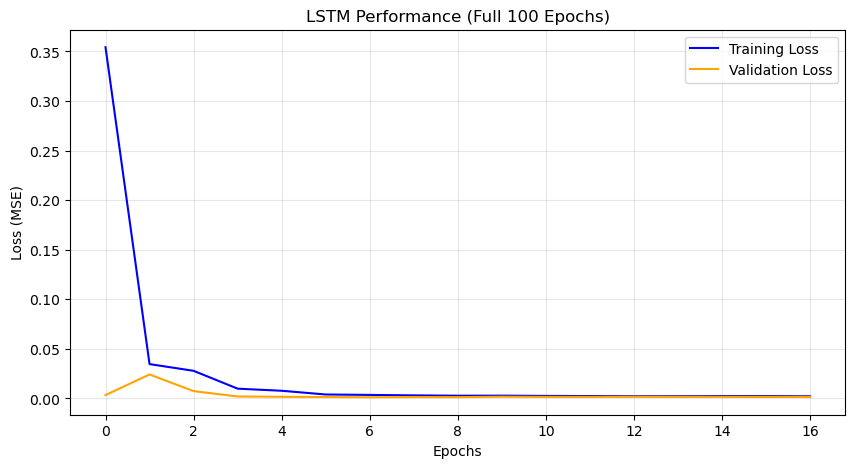

In [27]:
# ==========================================================
# LSTM MODEL TRAINING
# ==========================================================
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np
import random
import os


def fix_seeds(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    tf.random.set_seed(seed_value)


# Apply global SEED
fix_seeds(SEED)

def build_model(input_shape):

    model = models.Sequential([

        layers.Input(shape=input_shape),

        layers.Conv1D(
            filters=64,
            kernel_size=3,
            activation='relu',
            padding='same'
        ),

        layers.Dropout(0.2),

        layers.Conv1D(
            filters=32,
            kernel_size=3,
            activation='relu',
            padding='same'
        ),

        layers.GlobalMaxPooling1D(),

        layers.Dense(25, activation='relu'),

        layers.Dense(1)

    ])

    return model

early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=EARLY_STOP_PATIENCE,
    restore_best_weights=True
)

# Initialize model based on 3D tensor shape
input_shape = (X_processed_first.shape[1], X_processed_first.shape[2])
model = build_model(input_shape)

# Simple compilation
model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# Fit using global EPOCHS and BATCH_SIZE
history = model.fit(
    X_processed_first, y_processed_first,
    validation_data=(X_processed_last, y_processed_last),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=0
)


print("\n🏗️ Model Architecture Created:")
model.summary()

# Plot training performance
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title(f"LSTM Performance (Full {EPOCHS} Epochs)")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Generating final visualization for SPDB...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


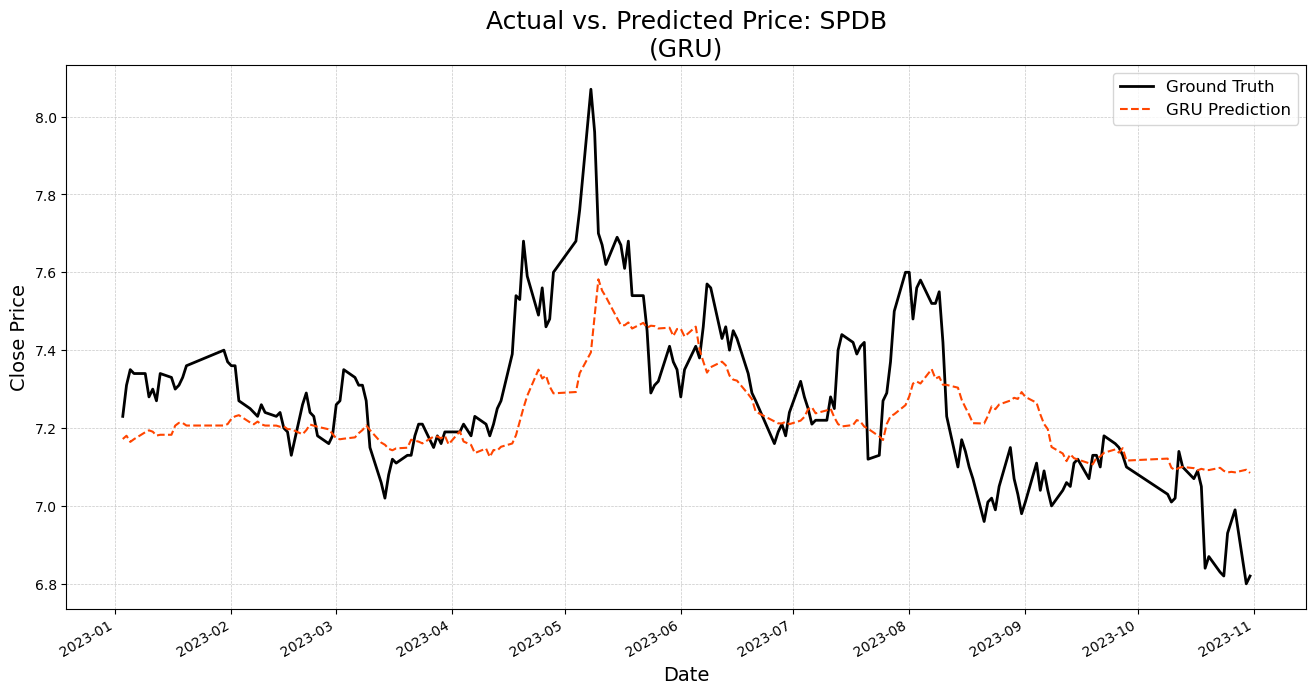

In [28]:
# ==========================================================
# Visualizing ACTUAL VS. PREDICTED
# ==========================================================
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

print(f"Generating final visualization for {TARGET_STOCK}...")

# Predict and reverse scaling to original price units
predicted_norm = model.predict(X_processed_last)
predicted_stock_price = scaler_first_y.inverse_transform(predicted_norm)
real_stock_price = scaler_first_y.inverse_transform(
    y_processed_last.reshape(-1, 1)
)

# Extract dates for the test period
test_len = len(real_stock_price)
# test_dates = stock_df.index[-test_len:]
test_dates = scaled_last_y_df.index[WINDOW_SIZE:]

# Create plotting dataframe
plot_data = pd.DataFrame({
    'Actual Price': real_stock_price.flatten(),
    'Predicted Price': predicted_stock_price.flatten()
}, index=test_dates)

# Plotting configuration
plt.figure(figsize=(16, 8))
plt.title(f'Actual vs. Predicted Price: {TARGET_STOCK}\n(GRU)', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)

# Ground Truth and Model Prediction
plt.plot(plot_data['Actual Price'],
         label='Ground Truth',
         color='black', linewidth=2)
plt.plot(plot_data['Predicted Price'],
         label='GRU Prediction',
         color='orangered',
         linestyle='--', linewidth=1.5)

# Formatting
plt.legend(fontsize=12, loc='upper right')
plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
plt.gcf().autofmt_xdate()

plt.show()

In [29]:
# ==========================================================
# FINAL EVALUATION METRICS (SCIENTIFIC COMPARISON SCALE)
# ==========================================================
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
import math

# Calculations for Normalized Scale (0-1)
n_rmse = math.sqrt(mean_squared_error(y_processed_last, predicted_norm))
n_mae = mean_absolute_error(y_processed_last, predicted_norm)

# Calculations for Actual Price Scale
r2 = r2_score(real_stock_price, predicted_stock_price)
rmse_actual = math.sqrt(mean_squared_error(real_stock_price, predicted_stock_price))
mae_actual = mean_absolute_error(real_stock_price, predicted_stock_price)

# MAPE is scale-invariant (percentage is the same for both)
mape_val = np.mean(np.abs((real_stock_price - predicted_stock_price) / real_stock_price)) * 100

# Formatting MAPE strings to prevent alignment gaps
mape_str = f"{mape_val:.4f}%"

# Table Display with Correct Alignment
print(f"MODEL PERFORMANCE SUMMARY: {TARGET_STOCK}")
print("=" * 75)
print(f"{'Metric':<15} | {'Normalized Scale (0-1)':<25} | {'Actual Price Scale'}")
print("-" * 75)
print(f"{'RMSE':<15} | {n_rmse:<25.4f} | {rmse_actual:.4f}")
print(f"{'MAE':<15} | {n_mae:<25.4f} | {mae_actual:.4f}")
print(f"{'MAPE (%)':<15} | {mape_str:<25} | {mape_str}")
print(f"{'R2 Score':<15} | {r2:<25.4f} | {r2:.4f}")
print("=" * 75)
print(f"Total Test Samples Evaluated: {len(real_stock_price)}")

MODEL PERFORMANCE SUMMARY: SPDB
Metric          | Normalized Scale (0-1)    | Actual Price Scale
---------------------------------------------------------------------------
RMSE            | 0.0355                    | 0.1589
MAE             | 0.0269                    | 0.1206
MAPE (%)        | 1.6454%                   | 1.6454%
R2 Score        | 0.4155                    | 0.4155
Total Test Samples Evaluated: 199
